In [ ]:
from pathlib import Path
import importlib.util
import pickle
import yaml

repo_root = Path.cwd()
if not (repo_root / "results").exists():
    repo_root = repo_root.parent

plotting_path = repo_root / "src" / "adaptive_low_rank" / "plotting.py"
spec = importlib.util.spec_from_file_location("adaptive_low_rank_plotting", plotting_path)
plotting = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plotting)


def load_results(results_dir):
    results_dir = Path(results_dir)
    with (results_dir / "results.pkl").open("rb") as file:
        results = pickle.load(file)
    with (results_dir / "config.yml").open() as file:
        config = yaml.safe_load(file)
        dataset_name = config["dataset"]
    return results, dataset_name


In [2]:
results, experiment_name = load_results(repo_root / "results" / "cluster_expansion")

In [3]:
import numpy as np
from itertools import product

batch_max_n_candidates = 10

def selected_indices(run):
    indices = np.asarray(run["result"].indices)
    return set(indices[np.isfinite(indices)].astype(int))

def jaccard(set_a, set_b):
    union = set_a | set_b
    return len(set_a & set_b) / len(union) if union else 1.0

# Compare the sequential method with batch max at one candidate count and greedy.
runs_by_algorithm = {}
for run in results:
    if (
        run["algorithm"] == "batch_max"
        and run["parameters"].get("n_candidates") != batch_max_n_candidates
    ):
        continue

    runs_by_algorithm.setdefault(run["algorithm"], []).append(
        selected_indices(run)
    )

sequential = runs_by_algorithm["sequential"]
batch_max = runs_by_algorithm["batch_max"]
greedy = runs_by_algorithm["greedy"]

for name, comparison in [
    ("sequential vs batch_max", batch_max),
    ("sequential vs greedy", greedy),
]:
    scores = [
        jaccard(seq, other)
        for seq, other in product(sequential, comparison)
    ]
    print(
        f"{name}: mean={np.mean(scores):.4f}, "
        f"std={np.std(scores):.4f}, "
        f"min={np.min(scores):.4f}, max={np.max(scores):.4f}"
    )

sequential vs batch_max: mean=0.1406, std=0.0109, min=0.1236, max=0.1605
sequential vs greedy: mean=0.2024, std=0.0000, min=0.2024, max=0.2024


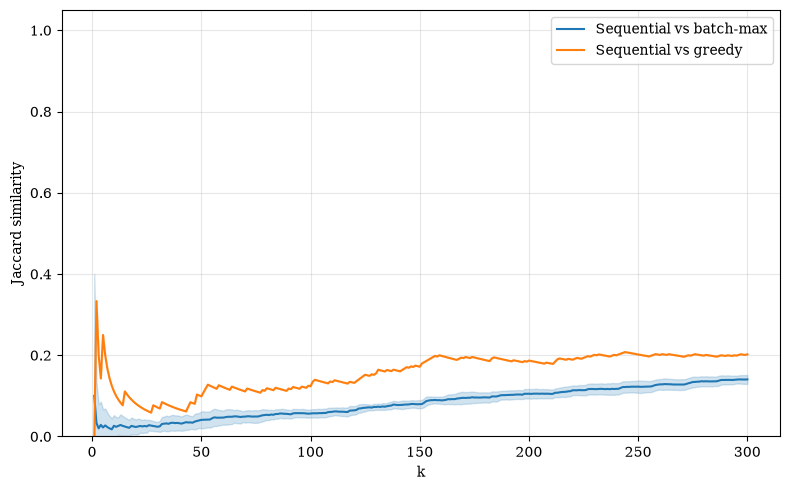

In [5]:
import matplotlib.pyplot as plt

def ordered_indices(run):
    indices = np.asarray(run["result"].indices)
    return indices[np.isfinite(indices)].astype(int)

def prefix_jaccard(indices_a, indices_b):
    max_k = min(len(indices_a), len(indices_b))
    values = []
    for k in range(1, max_k + 1):
        set_a = set(indices_a[:k])
        set_b = set(indices_b[:k])
        values.append(jaccard(set_a, set_b))
    return np.asarray(values)

sequential_runs = [
    ordered_indices(run)
    for run in results
    if run["algorithm"] == "sequential"
]

greedy_runs = [
    ordered_indices(run)
    for run in results
    if run["algorithm"] == "greedy"
]

batch_max_runs = [
    ordered_indices(run)
    for run in results
    if (
        run["algorithm"] == "batch_max"
        and run["parameters"].get("n_candidates") == batch_max_n_candidates
    )
]

def pairwise_curves(reference_runs, comparison_runs):
    return [
        prefix_jaccard(reference, comparison)
        for reference in reference_runs
        for comparison in comparison_runs
    ]

batch_curves = pairwise_curves(sequential_runs, batch_max_runs)
greedy_curves = pairwise_curves(sequential_runs, greedy_runs)

def plot_summary(curves, label, color):
    max_k = min(300, min(map(len, curves)))
    values = np.asarray([curve[:max_k] for curve in curves])
    k = np.arange(1, max_k + 1)
    mean = values.mean(axis=0)
    std = values.std(axis=0)

    plt.plot(k, mean, label=label, color=color)
    plt.fill_between(k, mean - std, mean + std, color=color, alpha=0.2)

plt.figure(figsize=(8, 5))
plot_summary(batch_curves, "Sequential vs batch-max", "tab:blue")
plot_summary(greedy_curves, "Sequential vs greedy", "tab:orange")

plt.xlabel("k")
plt.ylabel("Jaccard similarity")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()